<a id="perceptron"></a>
# The single perceptron

$$z = \sum_i w_i x_i + b \qquad y = \begin{cases} 1 & z > 0 \\ 0 & \text{otherwise}\end{cases}$$

A weighted sum, then a threshold. Nothing else.


In [ ]:
from viz import *


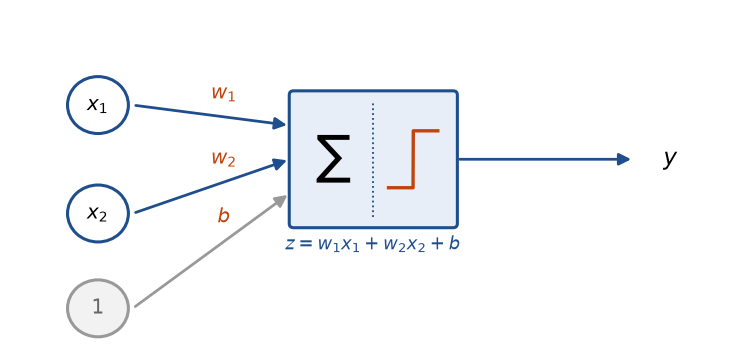

In [ ]:
diagram()


So let's see if we can use this perceptron to learn the **AND** function.

| $x_1$ | $x_2$ | $x_1 \wedge x_2$ |
|:-----:|:-----:|:----------------:|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | **1** |

Fire only when both inputs are on.


Start it off deliberately wrong. Then, for every corner it gets wrong, nudge
the weights in the direction that would have fixed it:

$$\text{error} = t - y \qquad w_i \mathrel{+}= \eta\,\text{error}\,x_i \qquad b \mathrel{+}= \eta\,\text{error}$$

Right answers change nothing. Only mistakes move the line.


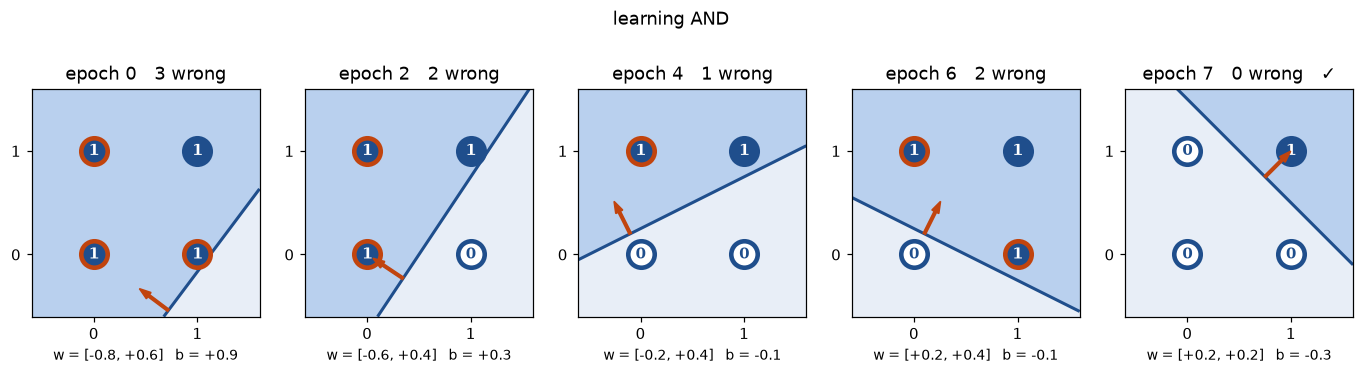

In [ ]:
learn()


## XOR

Now try **XOR** — fire when the inputs *disagree*.

| $x_1$ | $x_2$ | $x_1 \oplus x_2$ |
|:-----:|:-----:|:----------------:|
| 0 | 0 | 0 |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | 0 |

The two corners that must fire sit on one diagonal; the two that must stay
quiet sit on the other. **No single perceptron can ever learn this.**

Not "we haven't found the weights yet" — there are none. The perceptron's
output is decided by which side of the line $z = 0$ a point falls on, so
whatever $w$ and $b$ you choose, the 1s must end up on one side and the 0s on
the other. Here they interleave, and one straight line cannot separate one
diagonal from the other.

The learning rule will keep pushing forever and never settle.


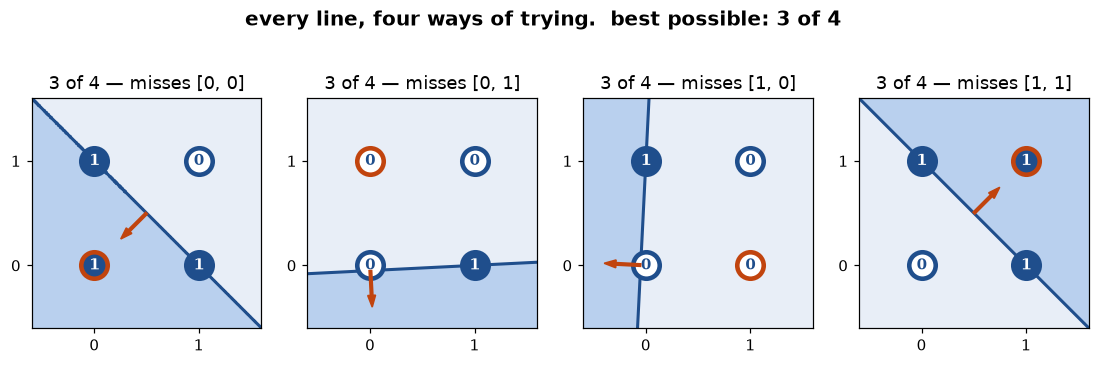

In [ ]:
no_line()


<a id="mlp"></a>
# The multiple layer perceptron


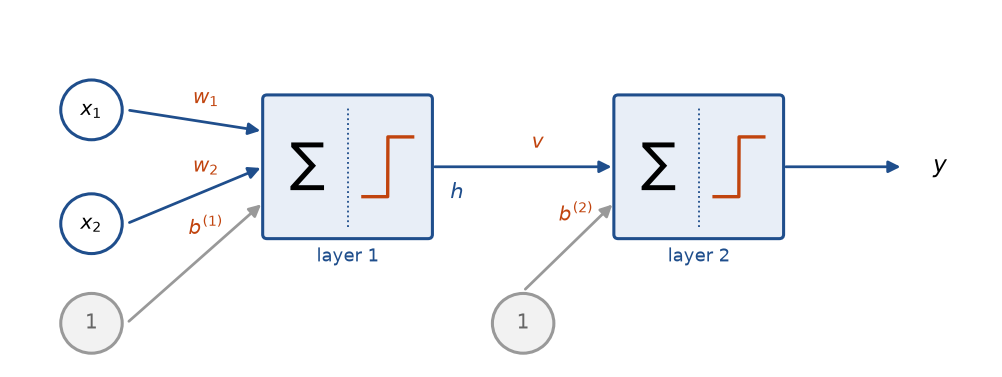

In [ ]:
mlp_diagram()


**This still can't do XOR.**

Layer 1 draws one line, and hands layer 2 a single bit $h$. Layer 2 sees nothing
but that bit, so all it can do is pass it on, invert it, or ignore it:

$$y = \text{step}(v\,h + b^{(2)}) \quad\Longrightarrow\quad y \in \{\,h,\ \text{not}\ h,\ 0,\ 1\,\}$$

The answer is still decided by which side of layer 1's single line you fell on.
Stacking bought nothing.

Depth is not the fix here — **width** is. Two neurons *side by side* in layer 1
draw two different lines, and layer 2 combines them. XOR is the strip between
them: above one line and below the other. That needs two lines, so it needs two
neurons in parallel.


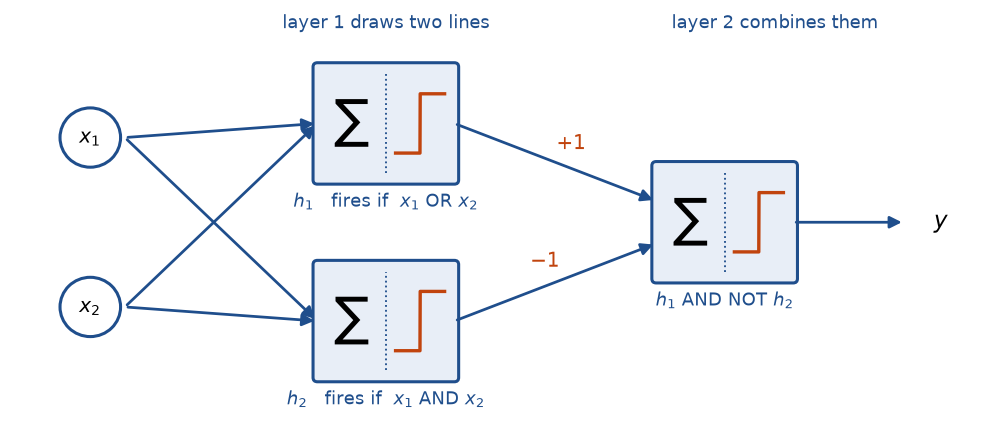

In [ ]:
xor_net_diagram()


**This one solves it.** Two neurons wide, then one to combine them:

$$h_1 = \text{step}(x_1 + x_2 - 0.5) \qquad h_2 = \text{step}(x_1 + x_2 - 1.5) \qquad y = \text{step}(h_1 - h_2 - 0.5)$$

$h_1$ is OR, $h_2$ is AND, and $y$ fires for *OR but not AND* — which is XOR.

| $x$ | $h_1$ | $h_2$ | $y$ |
|:--:|:--:|:--:|:--:|
| (0,0) | 0 | 0 | 0 |
| (0,1) | **1** | 0 | **1** |
| (1,0) | **1** | 0 | **1** |
| (1,1) | **1** | **1** | 0 |

Look at the middle two rows: the awkward diagonal corners now have **identical**
$(h_1, h_2)$. The hidden layer didn't draw a cleverer boundary — it moved the
points. In $(h_1, h_2)$ coordinates the two 1s have collapsed onto each other,
and a single line separates them from the rest. That line is layer 2.

Every neuron here is still a straight line. XOR is what you get by keeping one
and subtracting the other.

One catch: this network **exists**, but the learning rule from earlier cannot
find it. That rule only knows how to blame the neuron that produced the wrong
answer — it has nothing to say to a hidden neuron. Closing that gap is
backpropagation.


<a id="backprop"></a>
# Backpropagation


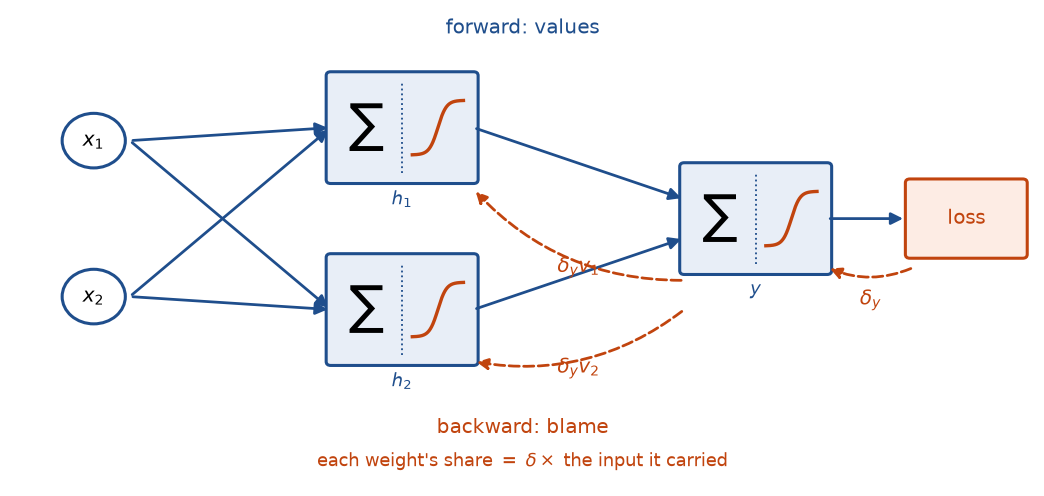

In [ ]:
backprop_diagram()
